## **_Assignment 2 – CNN Interpretability with CAM_**

### _Introduction_
In this assignment, we investigate how a pretrained Convolutional Neural Network (CNN) makes predictions using Class Activation Maps (CAM).

The goal is to understand **where the model focuses** in an image and how this relates to its prediction.

### _Model_

We use a pretrained **ResNet18** model trained on the ImageNet dataset (1000 classes).

**ResNet18** is a convolutional neural network with 18 layers. It is designed to solve common problems in deep networks, such as vanishing gradients, by using **skip connections** (also called residual connections).

These connections allow the model to pass information directly from earlier layers to later layers, which helps the network learn more effectively.

 
TorchCAM is used to visualize which parts of the image influence the model’s prediction.

In [403]:
# import libraries 

import torch
import json
import matplotlib.pyplot as plt

from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchvision.transforms.v2.functional import to_pil_image

from torchcam.methods import LayerCAM
from torchcam.utils import overlay_mask

# Load Model and  Weights

weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

preprocess = weights.transforms()

The JSON file is loaded into a dictionary where each class index maps to a class name, allowing us to convert the model’s prediction into a readable label.

In [404]:
# Load ImageNet Labels

with open("../Laboration 2/data/imagenet_class_index.json") as f:
    labels = json.load(f)

In [405]:
def run_cam(path, model, preprocess, labels):
    
    img = decode_image(path) #raed image till tensor
    input_tensor = preprocess(img) # prepare image for model

    with LayerCAM(model) as cam_extractor:
        out = model(input_tensor.unsqueeze(0)) # adds batch dimension
        pred = out.squeeze(0).argmax().item() # get predicted class
        cam = cam_extractor(pred, out) # creates heatmap for that class 

    probs = torch.softmax(out.squeeze(0), dim=0) # convert to probabilities
    top5_prob, top5_idx = torch.topk(probs, 5) # get top 5 predictions

    top5_labels = [labels[str(i.item())] for i in top5_idx] #Map to labels

    # Return original image ,CAM heatmap ,predicted class ,top 5 probabilities ,top 5 labels

    return img, cam, pred, top5_prob, top5_labels

### **Visualization**

In [406]:
def show_cam(img, cam, title=""):
    cam_map = cam[0].squeeze(0).numpy()
    #  Show heatmap
    plt.imshow(cam_map)
    plt.title("CAM Heatmap")
    plt.axis("off")
    plt.show()

    # Show overlay
    overlay = overlay_mask(
        to_pil_image(img),
        to_pil_image(cam[0].squeeze(), mode='F'),
        alpha=0.5
    )

    plt.imshow(overlay)
    plt.title(title)
    plt.axis("off")
    plt.show()

### **_Class Golden_retriever positive and Negative_**

In [407]:
img, cam, pred, probs, idx = run_cam(
    "../Laboration 2/data/retriever_p.jpg",
    model,
    preprocess,
    labels
)

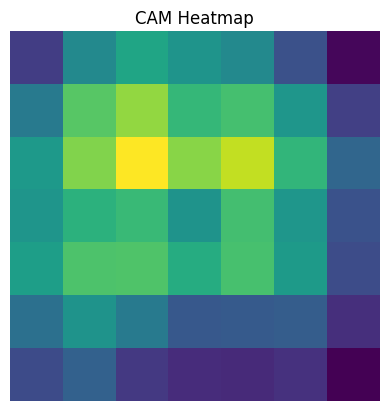

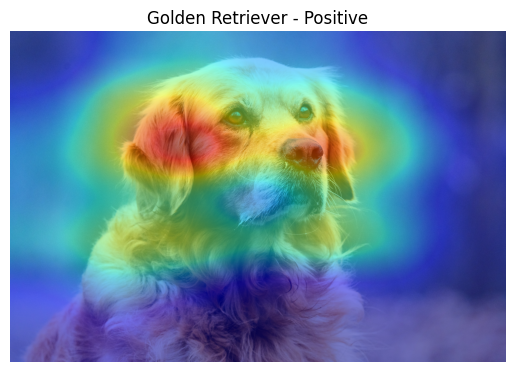

['n02099601', 'golden_retriever'] : 0.9066144824028015
['n02102318', 'cocker_spaniel'] : 0.03175653517246246
['n02100877', 'Irish_setter'] : 0.01591000147163868
['n02101388', 'Brittany_spaniel'] : 0.011637684889137745
['n02101556', 'clumber'] : 0.005067582707852125


In [408]:
img, cam, pred, probs, labels_top5 = run_cam(
    "../Laboration 2/data/retriever_p.jpg",
    model,
    preprocess,
    labels
)

show_cam(img, cam, "Golden Retriever - Positive")

for i in range(5):
    print(labels_top5[i], ":", probs[i].item())

### _Positive Example – Golden Retriever_

The model correctly predicts the image as a **golden retriever** with a confidence of **90.66%**.

The activation map shows that the model focuses mainly on the **head of the dog**, especially around the face area. This is a meaningful region, since features such as the shape of the head, ears, and fur are important for distinguishing dog breeds.

The top-5 predictions are all dog breeds (e.g. cocker spaniel, Irish setter), which indicates that the model understands that the image contains a dog, even if there is some uncertainty about the exact breed.

Overall, this is a good classification, as the model focuses on relevant features and predicts the correct class with high confidence.

In [409]:
img, cam, pred, probs, idx = run_cam(
    "../Laboration 2/data/retriever_n.jpg",
    model,
    preprocess,
    labels
)

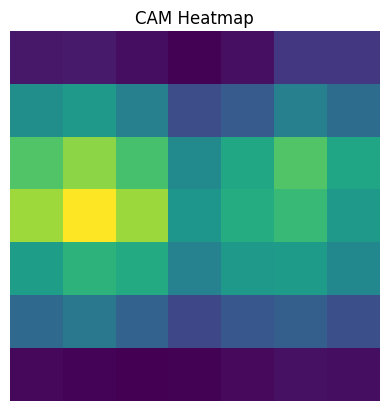

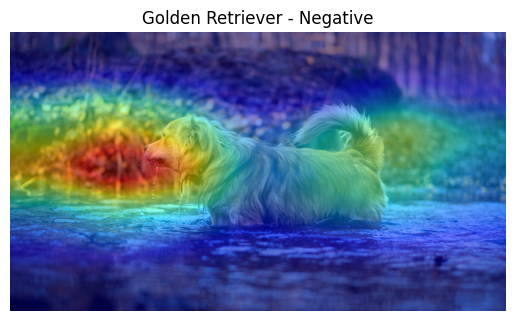

['n02099601', 'golden_retriever'] : 0.4489639699459076
['n02108551', 'Tibetan_mastiff'] : 0.1699211448431015
['n02111129', 'Leonberg'] : 0.12175245583057404
['n02106030', 'collie'] : 0.03250306099653244
['n02096294', 'Australian_terrier'] : 0.02974972501397133


In [410]:
img, cam, pred, probs, labels_top5 = run_cam(
    "../Laboration 2/data/retriever_n.jpg",
    model,
    preprocess,
    labels
)

show_cam(img, cam, "Golden Retriever - Negative")

for i in range(5):
    print(labels_top5[i], ":", probs[i].item())

### Negative Example – Golden Retriever

The model predicts the image as a golden retriever, but with lower confidence (44.9%), indicating uncertainty.

The activation map shows that the model focuses more on the **background and tail** instead of important features like the head. This suggests that the model is not using the most relevant information.

The top-5 predictions include several different dog breeds, which further shows uncertainty. Although the prediction is correct, the model’s decision appears closer to a guess.

### **_Class timber_wolf Positive and Negative_**

In [411]:
img, cam, pred, probs, idx = run_cam(
    "../Laboration 2/data/wolf_p.jpg",
    model,
    preprocess,
    labels
)

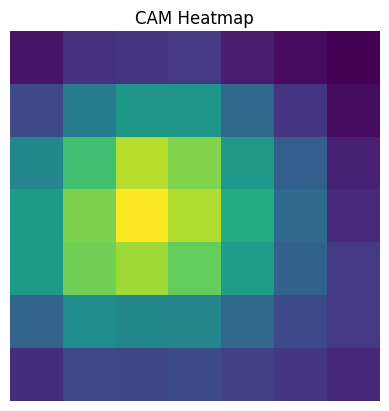

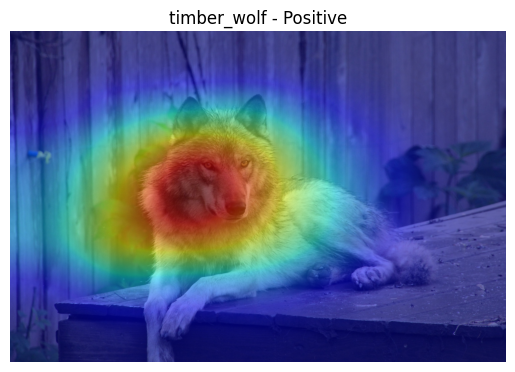

['n02114367', 'timber_wolf'] : 0.9048633575439453
['n02091467', 'Norwegian_elkhound'] : 0.039945121854543686
['n02114712', 'red_wolf'] : 0.017779292538762093
['n02114548', 'white_wolf'] : 0.009697680361568928
['n02109961', 'Eskimo_dog'] : 0.0063542858697474


In [412]:
img, cam, pred, probs, labels_top5 = run_cam(
    "../Laboration 2/data/wolf_p.jpg",
    model,
    preprocess,
    labels
)

show_cam(img, cam, "timber_wolf - Positive")

for i in range(5):
    print(labels_top5[i], ":", probs[i].item())

### Positive Example – Timber Wolf

The model correctly predicts the image as a timber wolf with high confidence (90.5%).

The activation map shows that the model focuses on the face of the wolf, which is a key region for identifying the animal. This indicates that the model is using relevant features.

The top-5 predictions include similar wolf and dog-related classes, showing that the model understands the general category well. Overall, this is a strong and reliable classification.

In [413]:
img, cam, pred, probs, idx = run_cam(
    "../Laboration 2/data/wolf_n.jpg",
    model,
    preprocess,
    labels
)

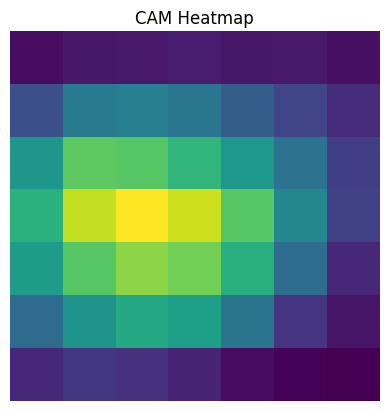

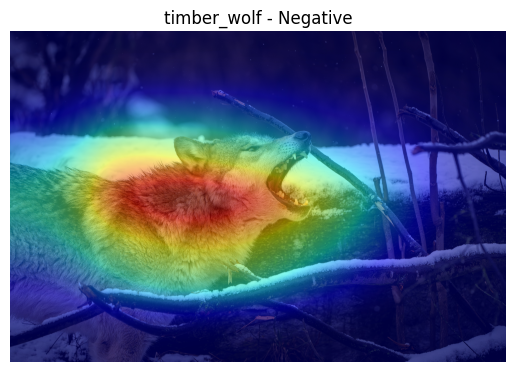

['n02114367', 'timber_wolf'] : 0.7987407445907593
['n02114712', 'red_wolf'] : 0.12499472498893738
['n02114855', 'coyote'] : 0.0648379921913147
['n02114548', 'white_wolf'] : 0.0062773446552455425
['n02120505', 'grey_fox'] : 0.0021882238797843456


In [414]:
img, cam, pred, probs, labels_top5 = run_cam(
    "../Laboration 2/data/wolf_n.jpg",
    model,
    preprocess,
    labels
)

show_cam(img, cam, "timber_wolf - Negative")

for i in range(5):
    print(labels_top5[i], ":", probs[i].item())

### Negative Example – Timber Wolf

The model predicts the image as a timber wolf with relatively high confidence (79.9%), but the activation map shows that it focuses on the neck and body rather than the face.

These regions are less informative for identifying the animal, suggesting that the model is not using the most relevant features.

The top-5 predictions include similar animals such as red wolf and coyote, indicating some uncertainty. Although the prediction is correct, the decision appears less reliable.

### **_Class Mud_turtule Positive and Negative_**

In [415]:
img, cam, pred, probs, idx = run_cam(
    "../Laboration 2/data/turtule_p.jpg",
    model,
    preprocess,
    labels
)

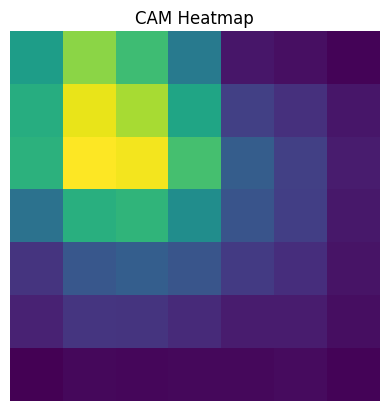

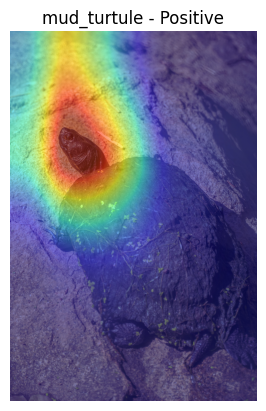

['n01667114', 'mud_turtle'] : 0.7001082897186279
['n01667778', 'terrapin'] : 0.10194265842437744
['n01641577', 'bullfrog'] : 0.07728829979896545
['n01669191', 'box_turtle'] : 0.0640474334359169
['n01737021', 'water_snake'] : 0.0086167361587286


In [416]:
img, cam, pred, probs, labels_top5 = run_cam(
    "../Laboration 2/data/turtule_p.jpg",
    model,
    preprocess,
    labels
)
show_cam(img, cam, "mud_turtule - Positive")

for i in range(5):
    print(labels_top5[i], ":", probs[i].item())

### Positive Example – Mud Turtle

The model correctly predicts the image as a mud turtle with a confidence of 70.0%.

The activation map shows that the model focuses on the head of the turtle, which is an important region for identifying the animal. This indicates that the model is using relevant features.

The top-5 predictions include similar classes such as terrapin and box turtle, showing that the model understands the general category. Overall, this is a good and reliable classification.

In [417]:
img, cam, pred, probs, idx = run_cam(
    "../Laboration 2/data/turtule_n.jpg",
    model,
    preprocess,
    labels
)

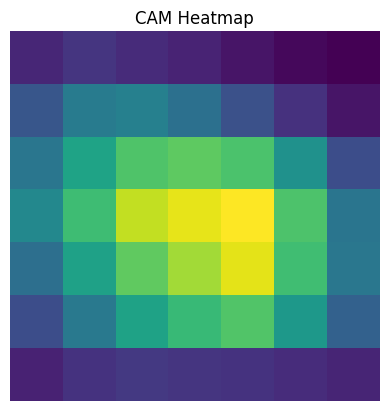

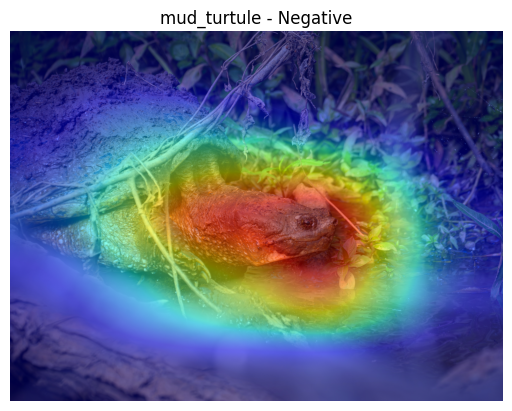

['n01737021', 'water_snake'] : 0.2985347807407379
['n02363005', 'beaver'] : 0.2324179857969284
['n01667114', 'mud_turtle'] : 0.1590939313173294
['n01641577', 'bullfrog'] : 0.15164974331855774
['n01698640', 'American_alligator'] : 0.06330389529466629


In [418]:
img, cam, pred, probs, labels_top5 = run_cam(
    "../Laboration 2/data/turtule_n.jpg",
    model,
    preprocess,
    labels
)
show_cam(img, cam, "mud_turtule - Negative")

for i in range(5):
    print(labels_top5[i], ":", probs[i].item())

### Negative Example – Mud Turtle

The model misclassifies the image as a water snake (29.9%), even though the correct class (mud turtle) appears in the top-5 predictions with lower confidence.

The activation map shows that the model focuses on the head, which is a relevant region. However, despite focusing on the correct area, the model still makes an incorrect prediction.

This suggests that the model confuses similar visual features, leading to a wrong classification even when attention is correctly placed.